<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

<h1>Lab: Convolutional Neural Network with TensorFlow</h1>

<h3>Objective for this Notebook</h3>
<h5>1. Learn how to use a Convolutional Neural Network to classify handwritten digits from the MNIST database</h5>
<h5>2. Learn how to reshape the images to make them faster to process</h5>

<h2>Table of Contents</h2>
<p>In this lab, we use TensorFlow to classify handwritten digits from the MNIST database and reshape the images to 16x16.</p>

<h2 id="Preparation">Preparation</h2>

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [19]:
# ---------------------------------
# Load MNIST Dataset
# ---------------------------------

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [20]:

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [21]:

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]


In [22]:

# ---------------------------------
# CNN Model
# ---------------------------------

model = tf.keras.Sequential([

    # Conv Layer 1
    tf.keras.layers.Conv2D(filters=16,kernel_size=(5,5),padding="same",activation="relu",input_shape=(28,28,1) ),

    # Max Pooling 1
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Conv Layer 2
    tf.keras.layers.Conv2D(filters=32,kernel_size=(5,5),padding="same",activation="relu" ),

    # Max Pooling 2
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(100, activation="relu"),

    # Output Layer
    tf.keras.layers.Dense(10)
])

c:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:


# ---------------------------------
# Compile Model
# ---------------------------------

learning_rate = 0.1

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [24]:
# Train Model
# ---------------------------------

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=3,
    batch_size=100,
    verbose=1
)

Epoch 1/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.9141 - loss: 0.2786 - val_accuracy: 0.9689 - val_loss: 0.0909
Epoch 2/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9770 - loss: 0.0717 - val_accuracy: 0.9813 - val_loss: 0.0521
Epoch 3/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9862 - val_loss: 0.0405


In [25]:
# ---------------------------------
# Evaluate Model
# ---------------------------------

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)


Validation Loss : 0.040522221475839615
Validation Accuracy : 0.9861999750137329


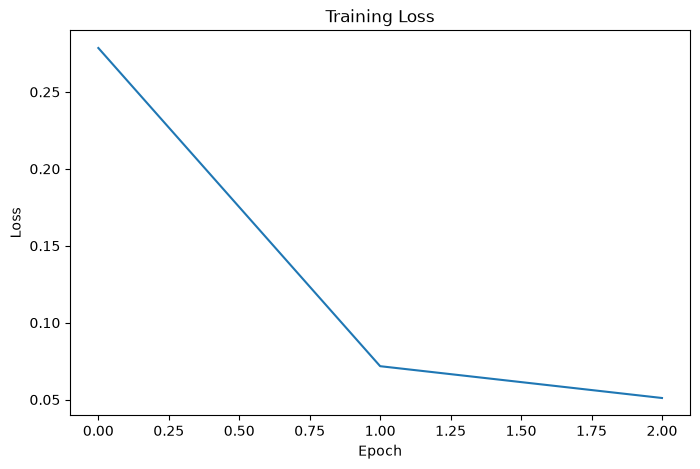

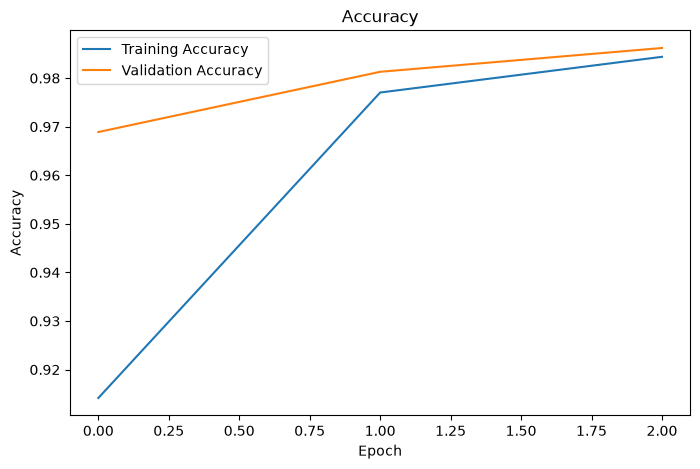

In [26]:
# ---------------------------------
# Plot Loss
# ---------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ---------------------------------
# Plot Accuracy
# ---------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


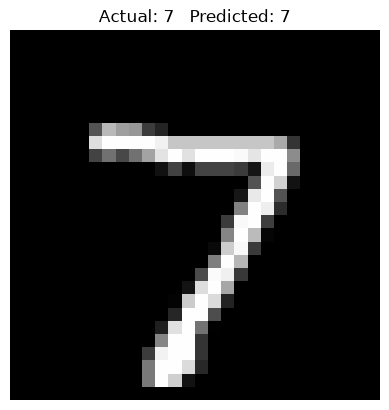

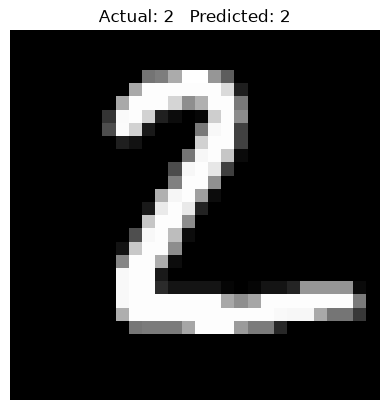

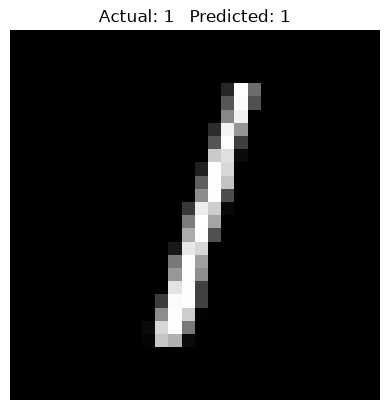

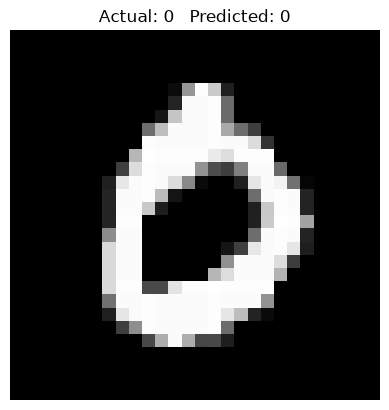

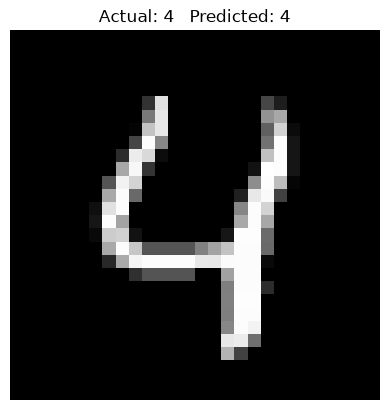

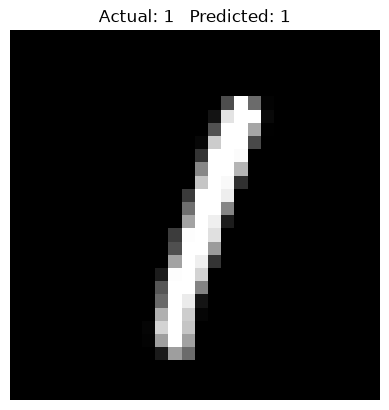

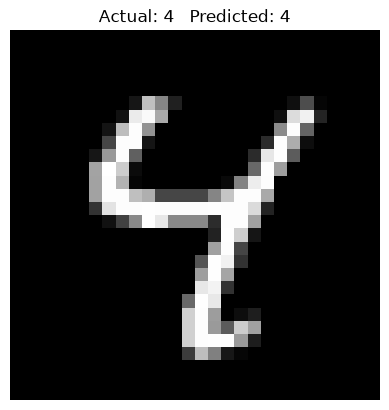

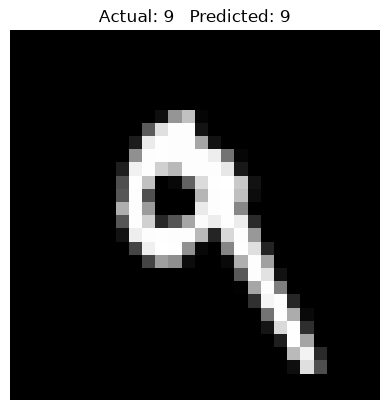

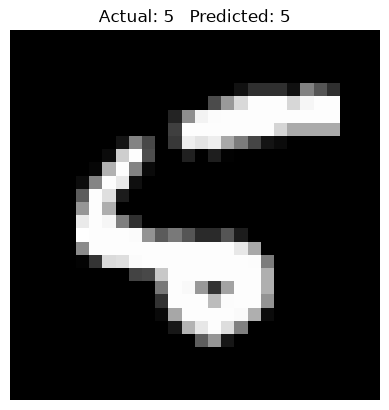

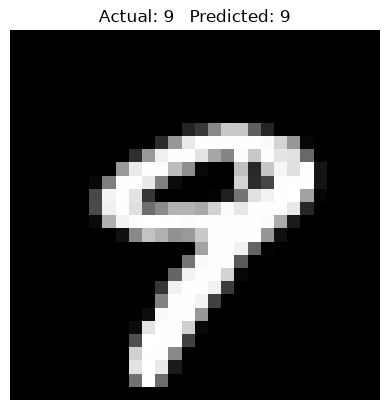

In [28]:

# ---------------------------------
# Predict First 5 Images
# ---------------------------------

predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

for i in range(10):
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Actual: {y_test[i]}   Predicted: {predicted_labels[i]}")
    plt.axis("off")
    plt.show()